In [1]:
# Setup and IBM backend connection

from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from time import sleep
from broadcasting import generate_qiskit_circuit, add_fidelity
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from datetime import datetime

np.set_printoptions(linewidth=200, precision=3, suppress=True)

service = QiskitRuntimeService(name="mprest1")


management.get:WARNING:2026-05-13 13:41:54,600: Loading saved account: mprest1


State: Ry(2.4315) Rz(2.7576) |0⟩
Circuit depth (unbound): 36
Total qubits: 9  (5 data + 4 ancilla)


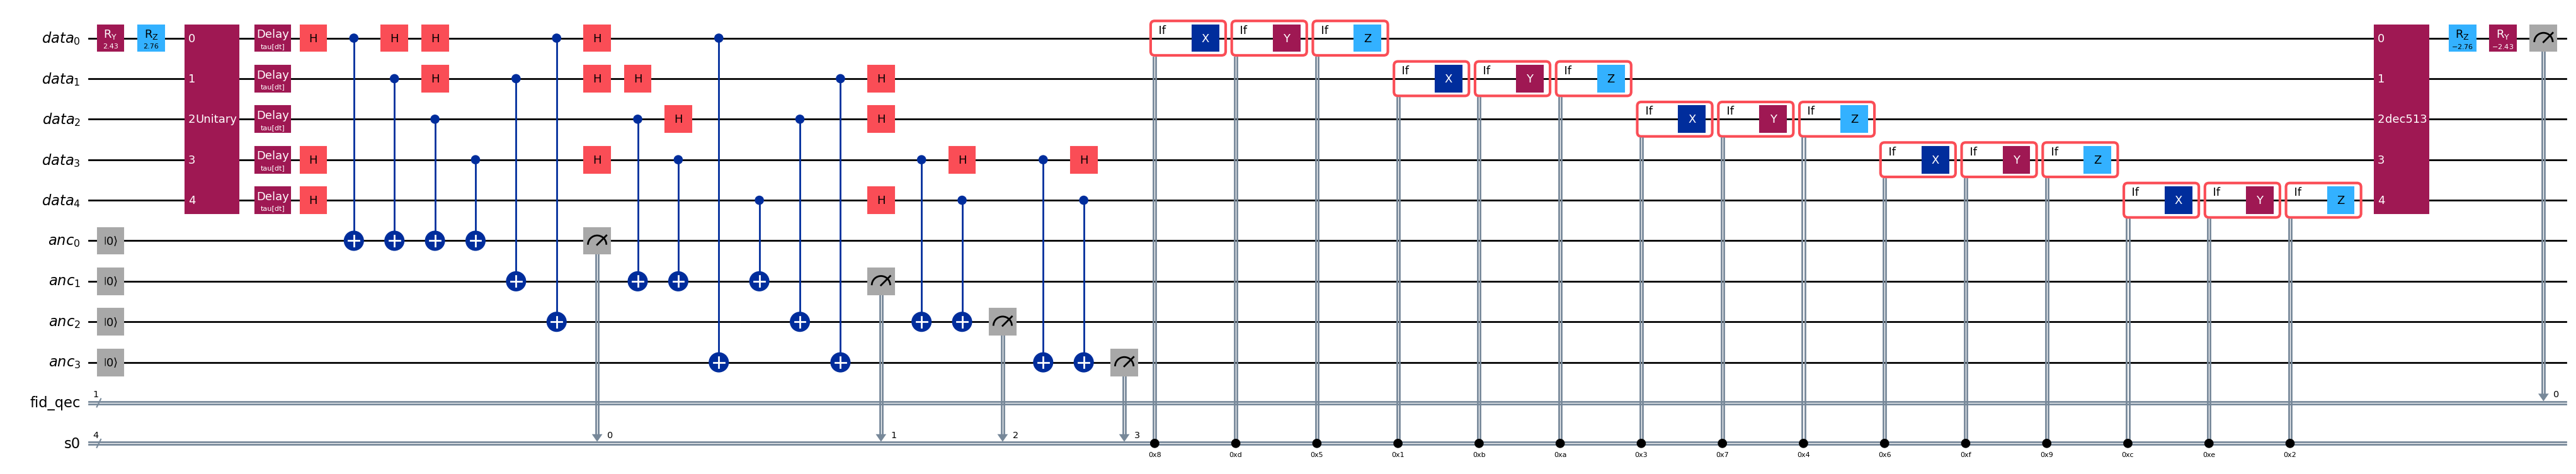

In [2]:

# QEC [[5,1,3]] fidelity benchmark
# Prepares a random phase state, encodes it into the [[5,1,3]] code, applies
# a parametric time delay, decodes (with syndrome correction), and measures
# the fidelity of the recovered qubit.

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from broadcasting.qec_513 import five_qubit_decode_gate, decode_qec_513
seed = 42
rng = np.random.default_rng(seed)

# --- Parameters ---
theta_qec = float(rng.uniform(0, np.pi))      # polar angle for |ψ⟩ = Ry(θ)|0⟩
phi_qec   = float(rng.uniform(0, 2 * np.pi))  # azimuthal angle (Rz(φ) applied after Ry)
tau_qec   = Parameter("tau")                   # delay duration in dt units
shots_qec = 8192

# --- Build the encode gate = adjoint of decode gate ---
decode_gate = five_qubit_decode_gate()
encode_gate = decode_gate.adjoint()   # maps |00000⟩ → |0_L⟩, |00001⟩ → |1_L⟩

# --- Registers ---
data = QuantumRegister(5, "data")         # [[5,1,3]] physical block
anc  = QuantumRegister(4, "anc")          # ancilla for syndrome measurement
fid  = ClassicalRegister(1, "fid_qec")   # fidelity readout

qc_qec = QuantumCircuit(data, anc, fid)

# 1. Prepare random phase state on data[0]
qc_qec.ry(theta_qec, data[0])
qc_qec.rz(phi_qec,   data[0])

# 2. Encode into [[5,1,3]] block
qc_qec.append(encode_gate, data[:])

# 3. Parametric delay on every physical qubit in the block
for q in data:
    qc_qec.delay(tau_qec, q)

# 4. Decode (syndrome extraction, classical feedforward, decode unitary)
#    Reuse the ancilla register we already added.
decoded_qubits = decode_qec_513(qc_qec, [list(data)], ancilla_qubits=list(anc))
decoded_q = decoded_qubits[0]   # index of the logical qubit after decoding

# 5. Inverse state preparation on decoded qubit → fidelity = P(|0⟩)
qc_qec.rz(-phi_qec,   decoded_q)
qc_qec.ry(-theta_qec, decoded_q)
qc_qec.measure(decoded_q, fid[0])

print(f"State: Ry({theta_qec:.4f}) Rz({phi_qec:.4f}) |0⟩")
print(f"Circuit depth (unbound): {qc_qec.depth()}")
print(f"Total qubits: {qc_qec.num_qubits}  (5 data + 4 ancilla)")
qc_qec.draw("mpl", fold=120)


Tau sweep: 21 values from 0 to 6000 dt
Noise-free mean fidelity: 1.0000
Noise-free min fidelity:  1.0000


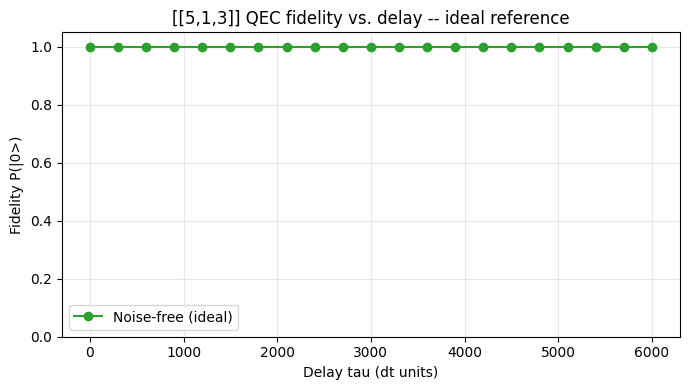

In [10]:
# QEC [[5,1,3]] fidelity vs. delay sweep -- Step 1: build sweep + noise-free reference.
#
# We bind the `tau` parameter to a range of delay durations (in dt units),
# run on a noise-free Aer simulator to get the ideal curve, and prepare
# the same circuit list for backend submission in the next cell.

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler

# --- Sweep parameters ---
tau_values_qec = np.linspace(0, 6000, 21).astype(int)
print(f"Tau sweep: {len(tau_values_qec)} values from {tau_values_qec[0]} to {tau_values_qec[-1]} dt")

# Build one bound circuit per tau value
qec_circuits = [qc_qec.assign_parameters({tau_qec: int(t)}) for t in tau_values_qec]

# --- Noise-free Aer simulation (ideal reference) ---
aer_sampler = AerSampler()
aer_pubs = [(c,) for c in qec_circuits]
aer_result = aer_sampler.run(aer_pubs, shots=shots_qec).result()

ideal_fidelities = []
for pub_res in aer_result:
    counts = pub_res.data.fid_qec.get_counts()
    total = sum(counts.values())
    p0 = sum(v for bs, v in counts.items() if bs[-1] == "0") / total
    ideal_fidelities.append(p0)

print(f"Noise-free mean fidelity: {np.mean(ideal_fidelities):.4f}")
print(f"Noise-free min fidelity:  {np.min(ideal_fidelities):.4f}")

# Quick preview plot of ideal curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tau_values_qec, ideal_fidelities, "o-", label="Noise-free (ideal)", color="tab:green")
ax.set_xlabel("Delay tau (dt units)")
ax.set_ylabel("Fidelity P(|0>)")
ax.set_title("[[5,1,3]] QEC fidelity vs. delay -- ideal reference")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# Step 2: transpile QEC sweep circuits and submit to a real IBM backend.
qec_backend = service.least_busy(simulator=False, operational=True, min_num_qubits=qc_qec.num_qubits)
print(f"Backend: {qec_backend.name}")
optimization_level = 3

qec_pm = generate_preset_pass_manager(backend=qec_backend, optimization_level=optimization_level)
qec_isa_circuits = qec_pm.run(qc_qec)


# qec_isa_circuits.draw("mpl", fold=120)

tau_values_qec = np.linspace(0, 6000, 21).astype(int)
print(f"Tau sweep: {len(tau_values_qec)} values from {tau_values_qec[0]} to {tau_values_qec[-1]} dt")

# Build one bound circuit per tau value
qec_circuits = [qec_isa_circuits.assign_parameters({tau_qec: int(t)}) for t in tau_values_qec]



qec_sampler = Sampler(mode=qec_backend)
qec_pubs = [(isc,) for isc in qec_circuits]
qec_job = qec_sampler.run(qec_pubs, shots=shots_qec)
print(f"Job ID: {qec_job.job_id()}")
print(f"Circuits submitted: {len(qec_pubs)}")
sleep(10)
print(f"Status: {qec_job.status()}")


Backend: ibm_kingston
Tau sweep: 21 values from 0 to 6000 dt
Job ID: d82agbntjchs73bnra7g
Circuits submitted: 21
Status: RUNNING


In [ ]:
# Step 3: collect backend results, compute fidelities, save JSON, plot ideal vs. backend.
qec_results = qec_job.result()

backend_fidelities = []
backend_counts_list = []
for pub_res in qec_results:
    counts = pub_res.data.fid_qec.get_counts()
    total = sum(counts.values())
    p0 = sum(v for bs, v in counts.items() if bs[-1] == "0") / total
    backend_fidelities.append(p0)
    backend_counts_list.append(counts)

# Print table
print(f"{'idx':>3}  {'tau':>6}  {'ideal':>8}  {'backend':>8}")
print("-" * 32)
for i, tau in enumerate(tau_values_qec):
    print(f"{i:>3}  {int(tau):>6}  {ideal_fidelities[i]:>8.4f}  {backend_fidelities[i]:>8.4f}")

# Save to timestamped JSON
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
qec_outfile = results_dir / f"qec513_delay_sweep_{timestamp}.json"

qec_run_data = {
    "timestamp": datetime.now().isoformat(),
    "experiment": "qec_513_delay_sweep",
    "job_id": qec_job.job_id(),
    "optimization_level": optimization_level,
    "backend": qec_backend.name,
    "shots": shots_qec,
    "seed": seed,
    "state_prep": {
        "theta": theta_qec,
        "phi": phi_qec,
        "description": "Ry(theta) Rz(phi) |0>",
    },
    "tau_values": [int(t) for t in tau_values_qec],
    "ideal_fidelities": [float(f) for f in ideal_fidelities],
    "backend_fidelities": [float(f) for f in backend_fidelities],
    "backend_counts": [dict(c) for c in backend_counts_list],
}
with open(qec_outfile, "w") as f:
    json.dump(qec_run_data, f, indent=2)
print(f"\nSaved results to {qec_outfile}")




idx     tau     ideal   backend
--------------------------------
  0       0    1.0000    0.4775
  1     300    1.0000    0.4821
  2     600    1.0000    0.4807
  3     900    1.0000    0.4889
  4    1200    1.0000    0.4762
  5    1500    1.0000    0.4873
  6    1800    1.0000    0.4847
  7    2100    1.0000    0.4777
  8    2400    1.0000    0.4769
  9    2700    1.0000    0.4790
 10    3000    1.0000    0.4917
 11    3300    1.0000    0.4719
 12    3600    1.0000    0.4883
 13    3900    1.0000    0.4805
 14    4200    1.0000    0.4874
 15    4500    1.0000    0.4813
 16    4800    1.0000    0.4832
 17    5100    1.0000    0.4869
 18    5400    1.0000    0.4852
 19    5700    1.0000    0.4868
 20    6000    1.0000    0.4709

Saved results to results/qec513_delay_sweep_20260513_123922.json


Saved plot to figures/qec513_delay_sweep_20260513_123922.png


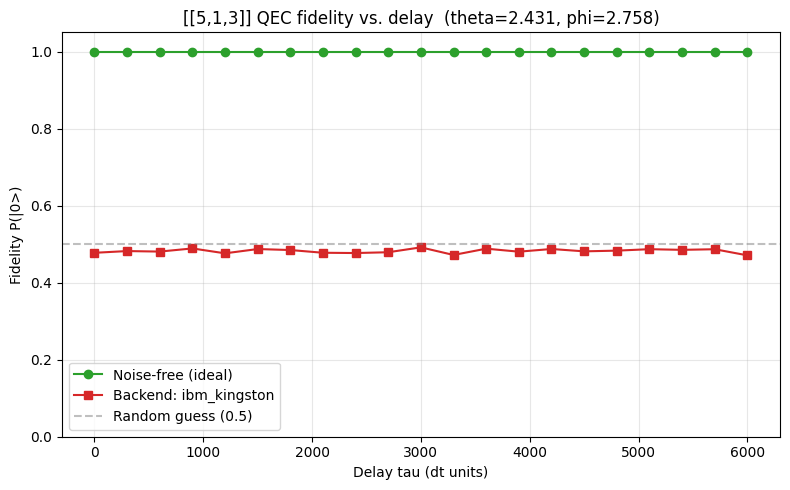

In [11]:
# Combined plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tau_values_qec, ideal_fidelities, "o-", label="Noise-free (ideal)", color="tab:green")
ax.plot(tau_values_qec, backend_fidelities, "s-", label=f"Backend: {qec_backend.name}", color="tab:red")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random guess (0.5)")
ax.set_xlabel("Delay tau (dt units)")
ax.set_ylabel("Fidelity P(|0>)")
ax.set_title(f"[[5,1,3]] QEC fidelity vs. delay  (theta={theta_qec:.3f}, phi={phi_qec:.3f})")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

fig_path = Path("figures") / f"qec513_delay_sweep_{timestamp}.png"
fig_path.parent.mkdir(exist_ok=True)
fig.savefig(fig_path, dpi=150)
print(f"Saved plot to {fig_path}")
plt.show()

M=1, N=2, QEC=False
nt=1 theta samples, 3 tau values -> 3 circuits
Theta samples (radians):
  [0] [5.928]


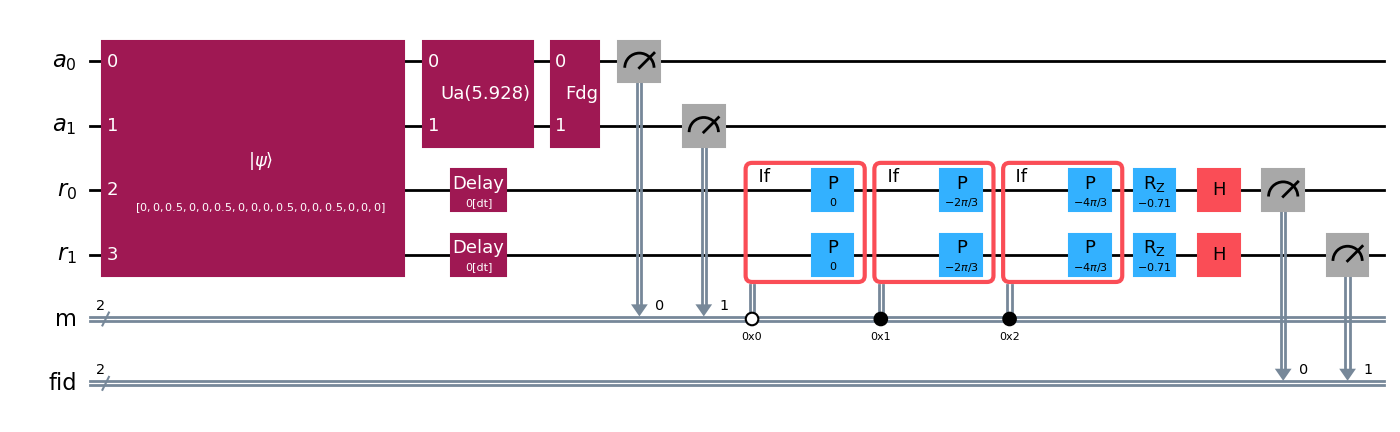

In [2]:
# Protocol parameters
M_senders = 1
N_receivers = 2
use_qec = False
shots = 8192
seed = 64

# Theta sweep: nt random samples per sender, uniform on [0, 2pi)
nt = 1
rng = np.random.default_rng(seed)
theta_samples = rng.uniform(0, 2 * np.pi, size=(nt, M_senders))

# Tau delay sweep (backend dt units). Use [0] to skip the delay dimension.
# tau_values = np.array([0])
tau_values = np.linspace(0, 6000, 3)

# Build one circuit per theta sample, bind tau for each
circuits = []
run_index = []  # (theta_idx, tau_val) for each circuit

for ti, thetas in enumerate(theta_samples):
    qc = generate_qiskit_circuit(
        M_senders, N_receivers, thetas.tolist(),
        use_receiver_qec_513=use_qec,
    )
    qc, reg_name, phi = add_fidelity(qc, N=N_receivers, thetas=thetas.tolist())
    tau_param = next(p for p in qc.parameters if p.name == "tau")

    for tau in tau_values:
        bound = qc.assign_parameters({tau_param: int(tau)})
        circuits.append(bound)
        run_index.append((ti, int(tau)))

print(f"M={M_senders}, N={N_receivers}, QEC={use_qec}")
print(f"nt={nt} theta samples, {len(tau_values)} tau values -> {len(circuits)} circuits")
print(f"Theta samples (radians):")
for ti, thetas in enumerate(theta_samples):
    print(f"  [{ti}] {thetas}")

# Printing circuit details for the first theta sample
circuits[0].draw("mpl", fold=100)

In [ ]:
# Transpile and submit to backend
backend = service.least_busy(simulator=False, operational=True)
print(f"Backend: {backend.name}")

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)
pubs = [(isc,) for isc in isa_circuits]
job = sampler.run(pubs, shots=shots)
print(f"Job ID: {job.job_id()}")
print(f"Circuits submitted: {len(pubs)}")
sleep(10)
print(f"Status: {job.status()}")

In [40]:
# Extract results, compute fidelities, save to file
results = job.result()
all_results = {}

for idx, ((ti, tau), pub_result) in enumerate(zip(run_index, results)):
    fid_data = getattr(pub_result.data, reg_name)
    counts = fid_data.get_counts()
    total = sum(counts.values())

    # BitArray.get_counts() returns per-register bitstrings (no spaces).
    # Qiskit convention: creg[i] = position i from the RIGHT of the bitstring.
    # So bitstr[-1-i] or equivalently bitstr[N-1-i] gives creg[i].
    fidelities = []
    for i in range(N_receivers):
        p0 = sum(v for bs, v in counts.items() if bs[N_receivers - 1 - i] == "0") / total
        fidelities.append(p0)

    key = f"theta_{ti}_tau_{tau}"
    all_results[key] = {
        "theta_idx": ti,
        "thetas": theta_samples[ti].tolist(),
        "tau": tau,
        "fidelities": fidelities,
        "counts": counts,
    }

# Print results table
thetas_str = "  ".join(f"theta_{j}" for j in range(M_senders))
recv_str = "  ".join(f"recv_{i}" for i in range(N_receivers))
print(f"{'idx':>3}  {'tau':>5}  {thetas_str}  |  {recv_str}")
print("-" * (12 + 8 * M_senders + 3 + 8 * N_receivers))
for key, data in all_results.items():
    ti, tau = data["theta_idx"], data["tau"]
    ts = "  ".join(f"{t:6.3f}" for t in data["thetas"])
    fs = "  ".join(f"{f:.4f}" for f in data["fidelities"])
    print(f"{ti:>3}  {tau:>5}  {ts}  |  {fs}")

# Save to timestamped JSON
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
outfile = results_dir / f"run_{timestamp}.json"

run_data = {
    "timestamp": datetime.now().isoformat(),
    "job_id": job.job_id(),
    "backend": backend.name,
    "shots": shots,
    "seed": seed,
    "protocol": {
        "M": M_senders,
        "N": N_receivers,
        "use_qec": use_qec,
        "nt": nt,
        "theta_samples": theta_samples.tolist(),
        "tau_values": [int(t) for t in tau_values],
    },
    "results": {
        key: {
            "theta_idx": data["theta_idx"],
            "thetas": data["thetas"],
            "tau": data["tau"],
            "fidelities": data["fidelities"],
            "counts": data["counts"],
        }
        for key, data in all_results.items()
    },
}

with open(outfile, "w") as f:
    json.dump(run_data, f, indent=2)
print(f"\nResults saved to {outfile}")

idx    tau  theta_0  |  recv_0  recv_1
---------------------------------------
  0      0   4.863  |  0.9391  0.9053
  0    150   4.863  |  0.9113  0.9260
  0    300   4.863  |  0.9076  0.9274
  0    450   4.863  |  0.9395  0.9049
  0    600   4.863  |  0.9091  0.9243
  0    750   4.863  |  0.8906  0.8344
  0    900   4.863  |  0.9128  0.8823
  0   1050   4.863  |  0.8827  0.8492
  0   1200   4.863  |  0.8524  0.8204
  0   1350   4.863  |  0.7845  0.7987
  0   1500   4.863  |  0.7927  0.7626
  0   1650   4.863  |  0.7566  0.7244
  0   1800   4.863  |  0.7114  0.6914
  0   1950   4.863  |  0.6757  0.6571
  0   2100   4.863  |  0.6420  0.6206
  0   2250   4.863  |  0.6080  0.5981
  0   2400   4.863  |  0.5782  0.5757
  0   2550   4.863  |  0.8298  0.5062
  0   2700   4.863  |  0.5198  0.5182
  0   2850   4.863  |  0.4956  0.5070
  0   3000   4.863  |  0.8241  0.4344
  0   3150   4.863  |  0.4937  0.4951
  0   3300   4.863  |  0.5048  0.4918
  0   3450   4.863  |  0.4979  0.5011
  0   360